In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import (
    average_precision_score, roc_auc_score, accuracy_score,
    precision_score, recall_score, f1_score, confusion_matrix,
    precision_recall_curve, roc_curve
)
import xgboost as xgb
import time
import warnings
warnings.filterwarnings('ignore')
import joblib
from scipy.stats import randint, uniform, loguniform
import time

In [2]:
# 1. Загрузка данных (уже разделённых)
FEATURES_TRAIN_PATH = "../model/features_train.npz"
FEATURES_TEST_PATH = "../model/features_test.npz"
PCA_PATH = "../model/pca.pkl"
SCALER_PATH = "../model/scaler.pkl"

data_train = np.load(FEATURES_TRAIN_PATH)
X_train = data_train["X"]
y_train = data_train["y"]

data_test = np.load(FEATURES_TEST_PATH)
X_test = data_test["X"]
y_test = data_test["y"]

print(f"Размерность X_train: {X_train.shape}")
print(f"Размерность X_test: {X_test.shape}")
print(f"Баланс классов train: {np.bincount(y_train)}")
print(f"Баланс классов test: {np.bincount(y_test)}")

# Загружаем PCA и scaler (для информации, не для трансформации – они уже применены)
with open(PCA_PATH, 'rb') as f:
    pca = pickle.load(f)
with open(SCALER_PATH, 'rb') as f:
    scaler = pickle.load(f)

Размерность X_train: (835, 96)
Размерность X_test: (209, 96)
Баланс классов train: [382 453]
Баланс классов test: [ 96 113]


In [3]:
# ========== 3. Балансировка классов ==========
# Вычисляем вес для положительного класса (галлюцинация = 1)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.3f}")

scale_pos_weight: 0.843


In [4]:
# 2. Настройка Hyperparameter Search
param_dist = {
    'n_estimators': randint(100, 600),
    'learning_rate': loguniform(0.005, 0.2),
    'max_depth': randint(3, 10),
    'min_child_weight': randint(1, 10),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 0.5),
    'reg_lambda': loguniform(0.1, 10.0),
    'reg_alpha': loguniform(0.1, 10.0)
}

base_model = xgb.XGBClassifier(
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    use_label_encoder=False,
    verbosity=0,
    scale_pos_weight=scale_pos_weight
)

# Стратифицированная 5‑fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# HalvingRandomSearchCV
search = HalvingRandomSearchCV(
    base_model, param_dist,
    resource='n_samples',        # Ресурс — количество строк (работает, как у вас)
    min_resources=110,
    factor=1.5,
    n_candidates=160,
    cv=cv,
    scoring='average_precision',
    random_state=42,
    n_jobs=1,
    verbose=1
)

print("Начинаем подбор гиперпараметров...")
start_time = time.time()
search.fit(X_train, y_train)
print(f"Подбор завершён за {time.time() - start_time:.2f} сек")

print("\nЛучшие параметры:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")
print(f"Лучший PR-AUC (CV): {search.best_score_:.4f}")

Начинаем подбор гиперпараметров...
n_iterations: 5
n_required_iterations: 13
n_possible_iterations: 5
min_resources_: 110
max_resources_: 835
aggressive_elimination: False
factor: 1.5
----------
iter: 0
n_candidates: 160
n_resources: 110
Fitting 5 folds for each of 160 candidates, totalling 800 fits
----------
iter: 1
n_candidates: 107
n_resources: 165
Fitting 5 folds for each of 107 candidates, totalling 535 fits
----------
iter: 2
n_candidates: 72
n_resources: 247
Fitting 5 folds for each of 72 candidates, totalling 360 fits
----------
iter: 3
n_candidates: 48
n_resources: 371
Fitting 5 folds for each of 48 candidates, totalling 240 fits
----------
iter: 4
n_candidates: 32
n_resources: 556
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Подбор завершён за 381.58 сек

Лучшие параметры:
  colsample_bytree: 0.6987504251354405
  gamma: 0.3481521364198942
  learning_rate: 0.06919428395295456
  max_depth: 7
  min_child_weight: 1
  n_estimators: 539
  reg_alpha: 0.118515156600

In [5]:
# ========== 6. Финальная модель с early_stopping ==========
best_params = search.best_params_
final_model = xgb.XGBClassifier(
    **best_params,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    use_label_encoder=False,
    verbosity=0,
    scale_pos_weight=scale_pos_weight,
    early_stopping_rounds=50   # early stopping на 50 раундов
)

# Обучаем на всём train, но с early_stopping на test
final_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,np.float64(0.6987504251354405)
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb

In [6]:
# ========== 7. Оценка метрик качества ==========
y_pred_proba = final_model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

pr_auc = average_precision_score(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("===== Метрики на ТЕСТОВОЙ выборке =====")
print(f"PR-AUC (average precision): {pr_auc:.4f}")
print(f"ROC-AUC:                   {roc_auc:.4f}")
print(f"Accuracy:                  {accuracy:.4f}")
print(f"Precision:                 {precision:.4f}")
print(f"Recall:                    {recall:.4f}")
print(f"F1-score:                  {f1:.4f}")

# ========== 8. Замер времени инференса ==========
# Прогрев модели (первый вызов может быть медленнее)
_ = final_model.predict_proba(X_test[:1])

# Замер на одном сэмпле (многократно для точности)
n_trials = 1000
single_times_ms = []
for i in range(n_trials):
    sample = X_test[i % len(X_test): i % len(X_test) + 1]  # берём один пример
    start = time.perf_counter()
    _ = final_model.predict_proba(sample)
    end = time.perf_counter()
    single_times_ms.append((end - start) * 1000)

avg_time_single = np.mean(single_times_ms)
max_time_single = np.max(single_times_ms)

# Замер на всём тестовом наборе (батч)
start_batch = time.perf_counter()
_ = final_model.predict_proba(X_test)
end_batch = time.perf_counter()
batch_time_total = (end_batch - start_batch) * 1000
avg_time_batch = batch_time_total / len(X_test)

print("\n===== Время инференса =====")
print(f"Среднее время на 1 сэмпл (из {n_trials} прогонов): {avg_time_single:.3f} мс")
print(f"Максимальное время на 1 сэмпл: {max_time_single:.3f} мс")
print(f"Среднее время на 1 сэмпл (по батчу из {len(X_test)} примеров): {avg_time_batch:.3f} мс")
print(f"Общее время на тестовый батч: {batch_time_total:.3f} мс")
print("✅ Все замеры значительно ниже лимита 500 мс")

===== Метрики на ТЕСТОВОЙ выборке =====
PR-AUC (average precision): 0.7459
ROC-AUC:                   0.7112
Accuracy:                  0.6603
Precision:                 0.6875
Recall:                    0.6814
F1-score:                  0.6844

===== Время инференса =====
Среднее время на 1 сэмпл (из 1000 прогонов): 0.476 мс
Максимальное время на 1 сэмпл: 16.825 мс
Среднее время на 1 сэмпл (по батчу из 209 примеров): 0.004 мс
Общее время на тестовый батч: 0.759 мс
✅ Все замеры значительно ниже лимита 500 мс


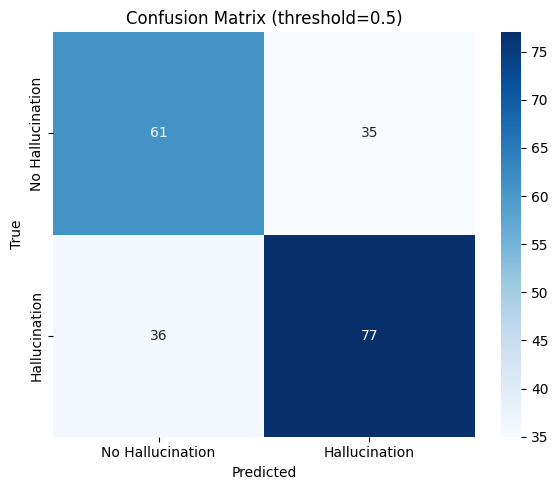

In [7]:
# 5. Визуализация результатов
# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Hallucination', 'Hallucination'],
            yticklabels=['No Hallucination', 'Hallucination'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (threshold=0.5)')
plt.tight_layout()
plt.savefig('../model/confusion_matrix.png')
plt.show()

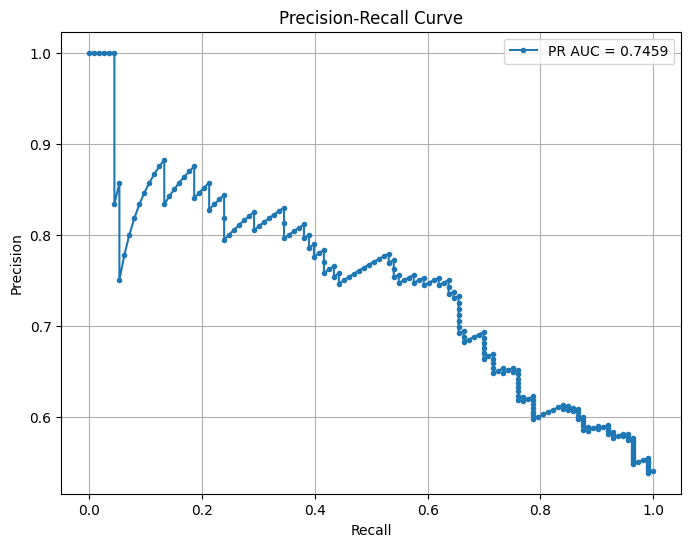

In [8]:
# PR-кривая
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_proba)
plt.figure(figsize=(8,6))
plt.plot(recall_curve, precision_curve, marker='.', label=f'PR AUC = {pr_auc:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.savefig('../model/pr_curve.png')
plt.show()

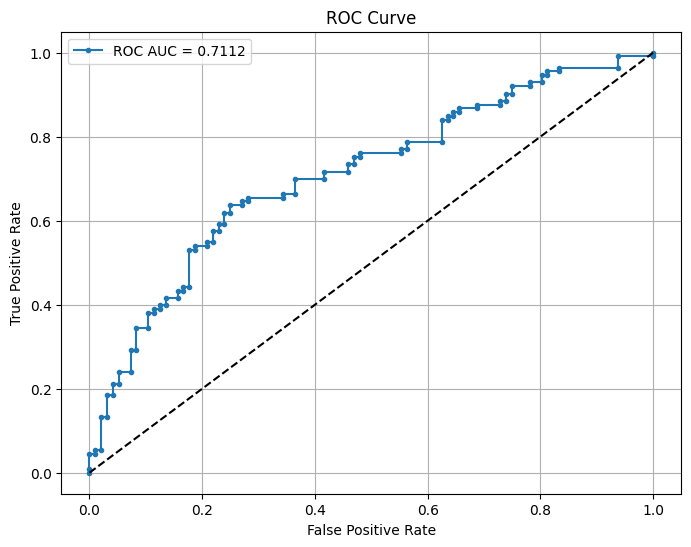

In [9]:
# ROC-кривая
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, marker='.', label=f'ROC AUC = {roc_auc:.4f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.savefig('../model/roc_curve.png')
plt.show()

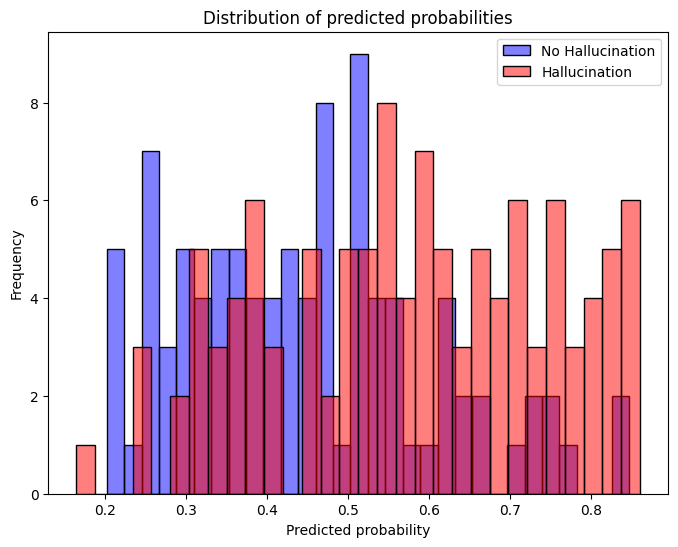

In [10]:
# Распределение вероятностей
plt.figure(figsize=(8,6))
sns.histplot(y_pred_proba[y_test==0], bins=30, color='blue', alpha=0.5, label='No Hallucination')
sns.histplot(y_pred_proba[y_test==1], bins=30, color='red', alpha=0.5, label='Hallucination')
plt.xlabel('Predicted probability')
plt.ylabel('Frequency')
plt.legend()
plt.title('Distribution of predicted probabilities')
plt.savefig('../model/proba_distribution.png')
plt.show()

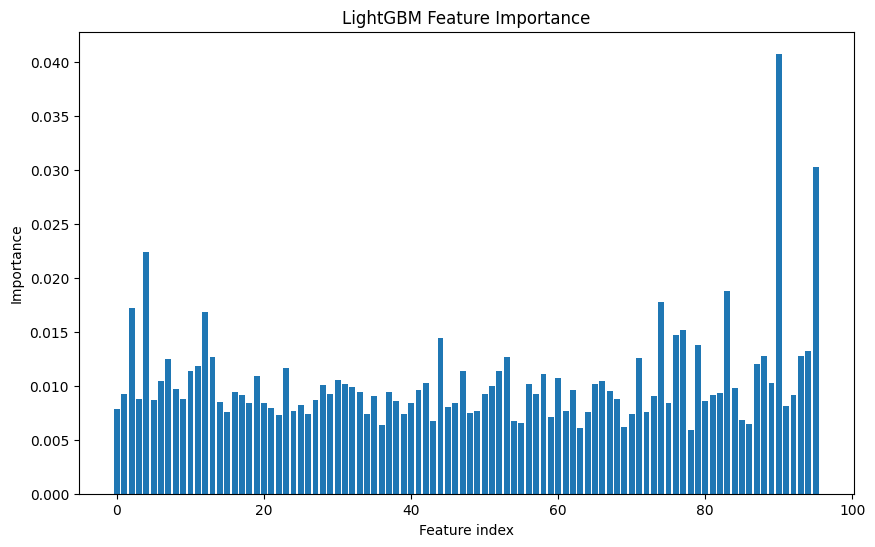

In [11]:
# Важность признаков
feature_importance = final_model.feature_importances_
plt.figure(figsize=(10,6))
plt.bar(range(len(feature_importance)), feature_importance)
plt.xlabel('Feature index')
plt.ylabel('Importance')
plt.title('LightGBM Feature Importance')
plt.savefig('../model/feature_importance.png')
plt.show()

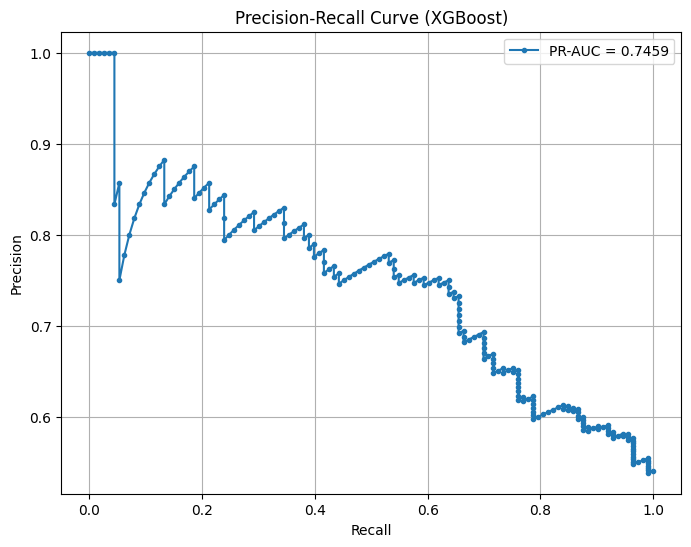

In [12]:
# Precision-Recall кривая
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label=f'PR-AUC = {pr_auc:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (XGBoost)')
plt.legend()
plt.grid(True)
plt.savefig('../model/pr_curve_xgboost.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# 6. Сохранение модели
joblib.dump(final_model, "../model/hallucination_detector.pkl")
print("Модель сохранена в model/hallucination_detector.pkl")

Модель сохранена в model/hallucination_detector.pkl
